# Predicting Banking sector Stock Prices Using LTSF-Linear Models

## Objectives:
- Predict the closing price of banking sector for the next 7 days

- Use historical windows of 7, 30, 120, and 480 days respectively

- Implement LTSF-Linear models: Linear, DLinear, NLinear

- Compare performance with baseline models



## 1. Import Libraries and Load Data


In [ ]:
!gdown 1VD9WX5pk3-gP0DU4VsoaXkJY8K774jzo
!gdown 1V7QqfnYu41iI1PLeuRHKJv1wIRZqtvFY
!unzip banking.zip

Downloading...
From: https://drive.google.com/uc?id=1VD9WX5pk3-gP0DU4VsoaXkJY8K774jzo
To: /content/banking.zip
100% 219k/219k [00:00<00:00, 33.1MB/s]
Downloading...
From: https://drive.google.com/uc?id=1V7QqfnYu41iI1PLeuRHKJv1wIRZqtvFY
To: /content/Gold.csv
100% 186k/186k [00:00<00:00, 14.2MB/s]
Archive:  banking.zip
   creating: banking/
  inflating: banking/BID.csv         
  inflating: banking/CTG.csv         
  inflating: banking/MBB.csv         
  inflating: banking/STB.csv         
  inflating: banking/VCB.csv         


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
import matplotlib.dates as mdates

from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.multioutput import MultiOutputRegressor
import lightgbm as lgb

import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
print(f"Device available: {'CUDA' if torch.cuda.is_available() else 'CPU'}")

Device available: CPU


VCB (Vietcombank): Niêm yết ngày 30/06/2009.

CTG (VietinBank): Niêm yết ngày 16/07/2009.

BID (BIDV): Niêm yết ngày 24/01/2014.

MBB (MBBank): Niêm yết ngày 01/11/2011.

STB (Sacombank): Niêm yết ngày 12/07/2006 (Ngân hàng đầu tiên lên sàn).

-----> Chọn mốc 05/01/2015 - 27/02/2026 cho tất cả các stock

In [ ]:
BID = pd.read_csv("banking/BID.csv")
CTG = pd.read_csv("banking/CTG.csv")
MBB = pd.read_csv("banking/MBB.csv")
STB = pd.read_csv("banking/STB.csv")
VCB = pd.read_csv("banking/VCB.csv")
Gold = pd.read_csv("Gold.csv")

In [ ]:
def convert_unit(val):
    if pd.isna(val) or val == '':
        return None

    val = str(val).upper().strip()


    units = {
        'K': 1_000,
        'M': 1_000_000,
        'B': 1_000_000_000,
        'T': 1_000_000_000_000
    }


    suffix = val[-1]
    if suffix in units:
        try:
            return float(val[:-1]) * units[suffix]
        except ValueError:
            return None


    try:
        return float(val)
    except ValueError:
        return None

In [ ]:
def data_cleaning(df):
  df = df.drop(columns="% Thay đổi")
  df = df.rename(columns={"Ngày": "time", "Lần cuối": "close", "Mở": "open", "Cao": "high", "Thấp": "low", "KL": "volume"})
  df['volume'] = df['volume'].apply(convert_unit)
  df['time'] = pd.to_datetime(df['time'], format='%d/%m/%Y')

  # Remove commas from string representations of numbers before converting to numeric
  df['close'] = pd.to_numeric(df['close'].str.replace(',', ''))
  df['high'] = pd.to_numeric(df['high'].str.replace(',', ''))
  df['open'] = pd.to_numeric(df['open'].str.replace(',', ''))
  df['low'] = pd.to_numeric(df['low'].str.replace(',', ''))
  df['volume'] = pd.to_numeric(df['volume'])

  df = df.sort_values('time').reset_index(drop=True)\

  return df

BID = data_cleaning(BID)
CTG = data_cleaning(CTG)
MBB = data_cleaning(MBB)
STB = data_cleaning(STB)
VCB = data_cleaning(VCB)
Gold = data_cleaning(Gold)

In [ ]:
print(f"Dataset shape: {BID.shape}")
print(f"Date range: {BID['time'].min()} to {BID['time'].max()}")
print("\nFirst few rows:")
display(BID.head())

print("\nData types:")
print(BID.dtypes)

print("\nBasic statistics:")
display(BID.describe())

Dataset shape: (2781, 6)
Date range: 2015-01-05 00:00:00 to 2026-02-27 00:00:00

First few rows:


,time,close,open,high,low,volume
0,2015-01-05,8197.0,8197.0,8260.6,8197.0,87400.0
1,2015-01-06,8387.7,8133.5,8451.2,8133.5,530810.0
2,2015-01-07,8641.8,8387.7,8641.8,8324.1,1090000.0
3,2015-01-08,8641.8,8641.8,8768.9,8514.7,1050000.0
4,2015-01-09,9213.7,8641.8,9213.7,8641.8,4330000.0



Data types:
time      datetime64[ns]
close            float64
open             float64
high             float64
low              float64
volume           float64
dtype: object

Basic statistics:


,time,close,open,high,low,volume
count,2781,2781.000000,2781.000000,2781.000000,2781.000000,2.781000e+03
mean,2020-07-31 09:17:40.194174976,28115.194822,28116.368968,28528.156023,27740.389464,2.789418e+06
min,2015-01-05 00:00:00,8197.000000,8133.500000,8260.600000,8133.500000,8.574000e+04
25%,2017-10-17 00:00:00,17423.500000,17356.200000,17641.200000,17112.700000,1.360000e+06
50%,2020-07-31 00:00:00,30896.600000,30935.600000,31301.000000,30585.300000,2.180000e+06
75%,2023-05-16 00:00:00,35744.000000,35702.000000,36128.800000,35297.800000,3.340000e+06
max,2026-02-27 00:00:00,55000.000000,55700.000000,56600.000000,54000.000000,2.854000e+07
std,NaN,10273.941516,10298.272155,10432.948761,10164.588078,2.455104e+06


In [ ]:
# Create Banking sector OHLCV data
def create_sector_ohlcv(stock_data_dict):
    """
    Create Banking sector OHLCV from multiple stocks

    stock_data_dict: dict
        {
            "VCB": df,
            "TCB": df,
            ...
        }

    df format:
        time | open | high | low | close | volume
    """

    dfs = []

    # ----- rename columns -----
    for ticker, df in stock_data_dict.items():
        df = df.copy()

        df = df.rename(columns={
            'open': f'{ticker}_open',
            'high': f'{ticker}_high',
            'low': f'{ticker}_low',
            'close': f'{ticker}_close',
            'volume': f'{ticker}_volume'
        })

        dfs.append(df)

    # ----- merge all stocks -----
    merged = dfs[0]

    for df in dfs[1:]:
        merged = pd.merge(merged, df, on="time", how="inner")

    merged = merged.sort_values("time")

    tickers = list(stock_data_dict.keys())

    sector = pd.DataFrame()
    sector["time"] = merged["time"]

    # ----- PRICE: arithmetic mean -----
    for col in ["open", "high", "low", "close"]:
        price_cols = [f"{t}_{col}" for t in tickers]
        sector[col] = merged[price_cols].mean(axis=1)

    # ----- VOLUME: sum -----
    volume_cols = [f"{t}_volume" for t in tickers]
    sector["volume"] = merged[volume_cols].sum(axis=1)

    return sector

In [ ]:
bank_data = {
    "BID": BID,
    "CTG": CTG,
    "MBB": MBB,
    "STB": STB,
    "VCB": VCB
}

df = create_sector_ohlcv(bank_data)

print(df.head())

        time     open      high      low     close      volume
0 2015-01-05  9239.94   9372.40  9204.76   9281.02   2786670.0
1 2015-01-06  9237.52   9695.58  9229.46   9608.92  18016560.0
2 2015-01-07  9638.48   9823.72  9485.80   9668.76  16069640.0
3 2015-01-08  9655.90   9914.08  9603.74   9784.32   8613460.0
4 2015-01-09  9832.26  10321.24  9824.18  10260.12  44170000.0


In [ ]:
Gold.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2479 entries, 0 to 2478
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   time    2479 non-null   datetime64[ns]
 1   close   2479 non-null   float64       
 2   open    2479 non-null   float64       
 3   high    2479 non-null   float64       
 4   low     2479 non-null   float64       
 5   volume  2477 non-null   float64       
dtypes: datetime64[ns](1), float64(5)
memory usage: 116.3 KB


## 2. Data Exploration and Target Variables Design


In [ ]:
# === STEP 2: FEATURE CREATION & MISSING VALUE DETECTION ===

# Create essential features
print("1. Creating essential features:")
df['daily_return'] = df['close'].pct_change()
df['close_log'] = np.log(df['close'])
for i in range(1, 8):
    df[f'return_{i}d'] = np.log(df['close'].shift(-i) / df['close'])
for i in [1, 2, 3, 4, 5, 6, 7, 10, 20, 30, 120, 480]:
    df[f'return_{i}d_past'] = np.log(df['close'] / df['close'].shift(i))

Gold['return_1d_past'] = np.log(df['close'] / df['close'].shift(1))
gold_df = Gold[['time', 'return_1d_past']]
gold_df = gold_df.rename(columns={'time': 'time', 'return_1d_past': 'gold_return'})
print(" - daily_return: daily percentage change")
print(" - close_log: logarithm of the closing price")

# Check missing values for ALL columns
missing_info = df.isnull().sum()

missing_info


1. Creating essential features:
 - daily_return: daily percentage change
 - close_log: logarithm of the closing price


,0
time,0
open,0
high,0
low,0
close,0
volume,0
daily_return,1
close_log,0
return_1d,1
return_2d,2


In [ ]:
df[df['volume'].isnull()]

,time,open,high,low,close,volume,daily_return,close_log,return_1d,return_2d,...,return_3d_past,return_4d_past,return_5d_past,return_6d_past,return_7d_past,return_10d_past,return_20d_past,return_30d_past,return_120d_past,return_480d_past


In [ ]:
# Bước 3: Missing Value Handling
# Handle only necessary missing values
if df['daily_return'].isnull().sum() > 0:
    df['daily_return'].fillna(0, inplace=True)

# Verify fix
missing_after = df.isnull().sum()
missing_after

,0
time,0
open,0
high,0
low,0
close,0
volume,0
daily_return,0
close_log,0
return_1d,1
return_2d,2


### 2.1. Feature Engineering

In [ ]:
# Lag features
def create_lag_features(df, cols, lags):

    for col in cols:
        for lag in lags:
            df[f'{col}_lag{lag}'] = df[col].shift(lag)

    return df

In [ ]:
# Momentum
def compute_kama(price, er_period=10, fast=2, slow=30):
    price = pd.Series(price)

    # 1. Efficiency Ratio
    change = price.diff(er_period).abs()
    volatility = price.diff().abs().rolling(er_period).sum()
    er = change / volatility

    # 2. Smoothing Constant
    fast_sc = 2 / (fast + 1)
    slow_sc = 2 / (slow + 1)
    sc = (er * (fast_sc - slow_sc) + slow_sc) ** 2

    # 3. Initialize KAMA
    kama = pd.Series(index=price.index)
    kama.iloc[er_period] = price.iloc[:er_period].mean()

    # 4. Recursive calculation
    for i in range(er_period + 1, len(price)):
        kama.iloc[i] = kama.iloc[i - 1] + sc.iloc[i] * (price.iloc[i] - kama.iloc[i - 1])

    return kama


df["KAMA_10"] = compute_kama(df["close"])
df["SMA_20"] = df["close"].rolling(20).mean()
df["HLC3"] = (df["high"] + df["low"] + df["close"]) / 3

In [ ]:
# Trend
def compute_ema(price, period=20):
    price = pd.Series(price)
    return price.ewm(span=period, adjust=False).mean()


def compute_wma(series, period):
    weights = np.arange(1, period + 1)
    return series.rolling(period).apply(
        lambda x: np.dot(x, weights) / weights.sum(),
        raw=True
    )

def compute_hma(price, period=20):
    price = pd.Series(price)

    half = int(period / 2)
    sqrt_period = int(np.sqrt(period))

    wma1 = compute_wma(price, half)
    wma2 = compute_wma(price, period)

    raw_hma = 2 * wma1 - wma2
    return compute_wma(raw_hma, sqrt_period)

def compute_fwma(price, period=10):
    price = pd.Series(price)

    fib = [1, 1]
    for _ in range(period - 2):
        fib.append(fib[-1] + fib[-2])

    weights = np.array(fib)
    weights = weights / weights.sum()

    return price.rolling(period).apply(
        lambda x: np.dot(x, weights),
        raw=True
    )
def compute_tema(price, period=20):
    price = pd.Series(price)
    ema1 = price.ewm(span=period, adjust=False).mean()
    ema2 = ema1.ewm(span=period, adjust=False).mean()
    ema3 = ema2.ewm(span=period, adjust=False).mean()
    return 3 * ema1 - 3 * ema2 + ema3

df["TEMA_20"] = compute_tema(df["close"], 20)
df["EMA_20"] = compute_ema(df["close"], 20)
df["HMA_20"] = compute_hma(df["close"], 20)
df["FWMA_10"] = compute_fwma(df["close"], 10)

In [ ]:
# Volatility
def compute_atr(high, low, close, period=14):
    """Average True Range - measures market volatility."""
    tr1 = high - low
    tr2 = (high - close.shift(1)).abs()
    tr3 = (low - close.shift(1)).abs()
    true_range = pd.concat([tr1, tr2, tr3], axis=1).max(axis=1)
    return true_range.ewm(span=period, adjust=False).mean()

def compute_bbl(close, period=20, num_std=2):
    """Bollinger Bands Lower Band = SMA - num_std * rolling std."""
    sma = close.rolling(period).mean()
    std = close.rolling(period).std()
    return sma - num_std * std

df["ATR_14"] = compute_atr(df["high"], df["low"], df["close"], period=14)
df["BBL_20"] = compute_bbl(df["close"], period=20, num_std=2)

In [ ]:
# Volume
def compute_obv(close, volume):
    """On Balance Volume - cumulative volume adjusted by price direction."""
    direction = np.sign(close.diff())
    direction.iloc[0] = 0
    return (direction * volume).cumsum()


def compute_pvt(close, volume):
    """Price Volume Trend - cumulative volume weighted by percentage price change."""
    return (close.pct_change() * volume).fillna(0).cumsum()

df["OBV"] = compute_obv(df["close"], df["volume"])
df["PVT"] = compute_pvt(df["close"], df["volume"])

In [ ]:
df.columns

Index(['time', 'open', 'high', 'low', 'close', 'volume', 'daily_return',
       'close_log', 'return_1d', 'return_2d', 'return_3d', 'return_4d',
       'return_5d', 'return_6d', 'return_7d', 'return_1d_past',
       'return_2d_past', 'return_3d_past', 'return_4d_past', 'return_5d_past',
       'return_6d_past', 'return_7d_past', 'return_10d_past',
       'return_20d_past', 'return_30d_past', 'return_120d_past',
       'return_480d_past', 'KAMA_10', 'SMA_20', 'HLC3', 'TEMA_20', 'EMA_20',
       'HMA_20', 'FWMA_10', 'ATR_14', 'BBL_20', 'OBV', 'PVT'],
      dtype='object')

In [ ]:
# Implement lag features
base_features = [
    'KAMA_10',
    'SMA_20',
    'HLC3',
    'EMA_20',
    'HMA_20',
    'ATR_14',
    'BBL_20',
    'OBV',
    'PVT',
    'TEMA_20',
    'FWMA_10'
]

return_features = ['return_1d_past', 'return_2d_past', 'return_5d_past', 'return_10d_past', 'return_20d_past']

lag_features = [
    'KAMA_10_lag1', 'KAMA_10_lag2',
       'KAMA_10_lag5', 'KAMA_10_lag10', 'KAMA_10_lag20', 'SMA_20_lag1',
       'SMA_20_lag2', 'SMA_20_lag5', 'SMA_20_lag10', 'SMA_20_lag20',
       'HLC3_lag1', 'HLC3_lag2', 'HLC3_lag5', 'HLC3_lag10', 'HLC3_lag20',
       'EMA_20_lag1', 'EMA_20_lag2', 'EMA_20_lag5', 'EMA_20_lag10',
       'EMA_20_lag20', 'HMA_20_lag1', 'HMA_20_lag2', 'HMA_20_lag5',
       'HMA_20_lag10', 'HMA_20_lag20', 'ATR_14_lag1', 'ATR_14_lag2',
       'ATR_14_lag5', 'ATR_14_lag10', 'ATR_14_lag20', 'BBL_20_lag1',
       'BBL_20_lag2', 'BBL_20_lag5', 'BBL_20_lag10', 'BBL_20_lag20',
       'OBV_lag1', 'OBV_lag2', 'OBV_lag5', 'OBV_lag10', 'OBV_lag20',
       'PVT_lag1', 'PVT_lag2', 'PVT_lag5', 'PVT_lag10', 'PVT_lag20',
]

lags = [1,2,5,10,20]
df = create_lag_features(df, base_features, lags)

target_cols = [f'return_{i}d' for i in range(1, 8)]
df = df.merge(gold_df, on="time", how="left")
df = df.dropna().reset_index(drop=True)

print("Lag features created.")
print("Shape:", df.shape)

Lag features created.
Shape: (1898, 94)


In [ ]:
technical_indicator = df.columns
technical_indicator[7:]

Index(['close_log', 'return_1d', 'return_2d', 'return_3d', 'return_4d',
       'return_5d', 'return_6d', 'return_7d', 'return_1d_past',
       'return_2d_past', 'return_3d_past', 'return_4d_past', 'return_5d_past',
       'return_6d_past', 'return_7d_past', 'return_10d_past',
       'return_20d_past', 'return_30d_past', 'return_120d_past',
       'return_480d_past', 'KAMA_10', 'SMA_20', 'HLC3', 'TEMA_20', 'EMA_20',
       'HMA_20', 'FWMA_10', 'ATR_14', 'BBL_20', 'OBV', 'PVT', 'KAMA_10_lag1',
       'KAMA_10_lag2', 'KAMA_10_lag5', 'KAMA_10_lag10', 'KAMA_10_lag20',
       'SMA_20_lag1', 'SMA_20_lag2', 'SMA_20_lag5', 'SMA_20_lag10',
       'SMA_20_lag20', 'HLC3_lag1', 'HLC3_lag2', 'HLC3_lag5', 'HLC3_lag10',
       'HLC3_lag20', 'EMA_20_lag1', 'EMA_20_lag2', 'EMA_20_lag5',
       'EMA_20_lag10', 'EMA_20_lag20', 'HMA_20_lag1', 'HMA_20_lag2',
       'HMA_20_lag5', 'HMA_20_lag10', 'HMA_20_lag20', 'ATR_14_lag1',
       'ATR_14_lag2', 'ATR_14_lag5', 'ATR_14_lag10', 'ATR_14_lag20',
       'BBL_2

In [ ]:
feature_cols = ['return_1d_past',
       'return_2d_past', 'return_3d_past', 'return_4d_past', 'return_5d_past',
       'return_6d_past', 'return_7d_past', 'return_10d_past',
       'return_20d_past', 'return_30d_past', 'return_120d_past',
       'return_480d_past', 'KAMA_10', 'SMA_20', 'HLC3', 'TEMA_20', 'EMA_20',
       'HMA_20', 'FWMA_10', 'ATR_14', 'BBL_20', 'OBV', 'PVT',]

In [ ]:
feature_cols.append("gold_return")

In [ ]:
missing_after = df.isnull().sum()
missing_after

,0
time,0
open,0
high,0
low,0
close,0
...,...
FWMA_10_lag2,0
FWMA_10_lag5,0
FWMA_10_lag10,0
FWMA_10_lag20,0


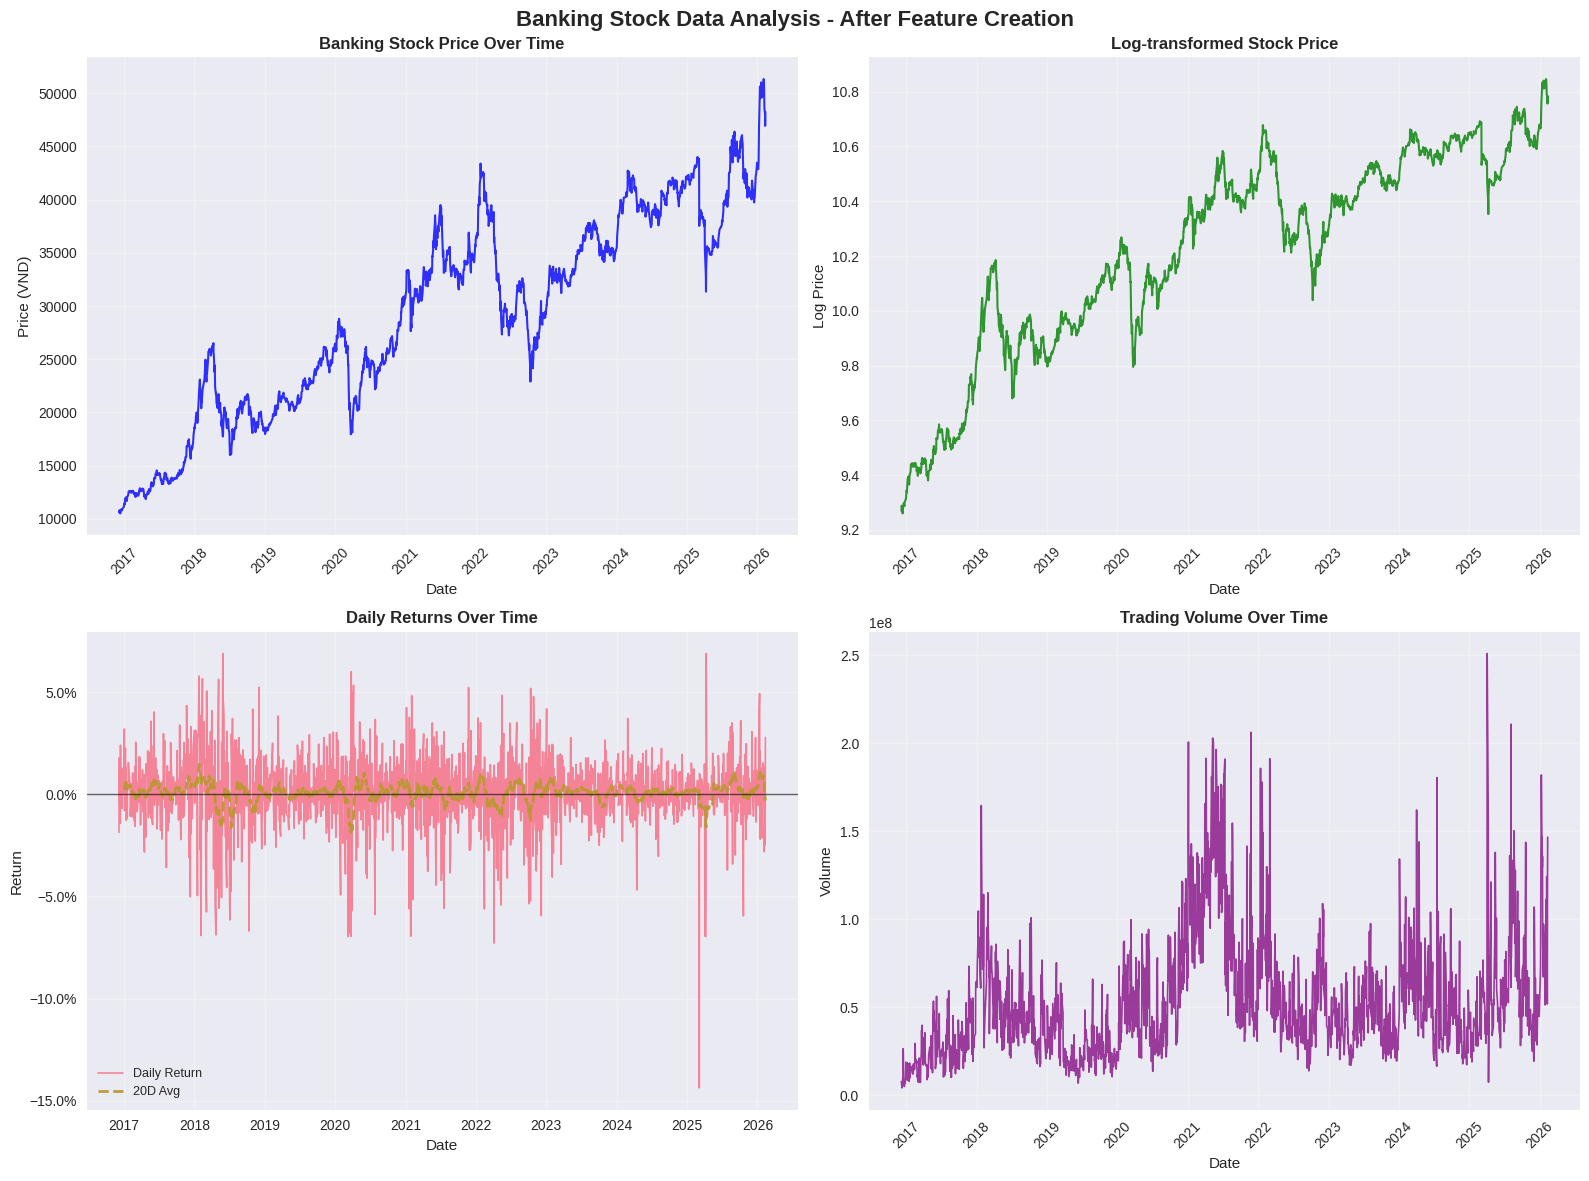

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Banking Stock Data Analysis - After Feature Creation', fontsize=16, fontweight='bold')

# 1) Stock Price Over Time
axes[0, 0].plot(df['time'], df['close'], linewidth=1.5, color='blue', alpha=0.8)
axes[0, 0].set_title('Banking Stock Price Over Time', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Date')
axes[0, 0].set_ylabel('Price (VND)')
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].tick_params(axis='x', rotation=45)

# 2) Log-transformed Price
axes[0, 1].plot(df['time'], df['close_log'], linewidth=1.5, color='green', alpha=0.8)
axes[0, 1].set_title('Log-transformed Stock Price', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Date')
axes[0, 1].set_ylabel('Log Price')
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].tick_params(axis='x', rotation=45)

# 3) Daily Returns Over Time (time-series thay histogram)
ret_ts = df[['time', 'daily_return']].dropna().copy()
ret_ts['ret_ma20'] = ret_ts['daily_return'].rolling(20).mean()

axes[1, 0].plot(ret_ts['time'], ret_ts['daily_return'], linewidth=1.2, alpha=0.85, label='Daily Return')
axes[1, 0].plot(ret_ts['time'], ret_ts['ret_ma20'], linewidth=2.0, linestyle='--', alpha=0.95, label='20D Avg')
axes[1, 0].axhline(0, color='black', linewidth=1, alpha=0.6)

axes[1, 0].set_title('Daily Returns Over Time', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Date')
axes[1, 0].set_ylabel('Return')
axes[1, 0].yaxis.set_major_formatter(PercentFormatter(1.0))
axes[1, 0].xaxis.set_major_locator(mdates.AutoDateLocator())
axes[1, 0].xaxis.set_major_formatter(mdates.ConciseDateFormatter(mdates.AutoDateLocator()))
axes[1, 0].tick_params(axis='x', rotation=0)
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].legend(fontsize=9)

# 4) Volume Over Time
axes[1, 1].plot(df['time'], df['volume'], linewidth=1.2, color='purple', alpha=0.75)
axes[1, 1].set_title('Trading Volume Over Time', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Date')
axes[1, 1].set_ylabel('Volume')
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## 3. Data Preparation and Time Series Dataset


In [ ]:
from sklearn.preprocessing import StandardScaler

def get_ml_formats(df, feature_cols, target_cols):

    # Feature columns = tất cả lag features

    X = df[feature_cols]
    y = df[target_cols]

    # Time series split
    train_end = int(len(df) * 0.7)
    val_end = int(len(df) * 0.85)

    X_train = X.iloc[:train_end]
    y_train = y.iloc[:train_end]

    X_val = X.iloc[train_end:val_end]
    y_val = y.iloc[train_end:val_end]

    X_test = X.iloc[val_end:]
    y_test = y.iloc[val_end:]

    # Scale features
    scaler_X = StandardScaler()
    scaler_y = StandardScaler()

    X_train = scaler_X.fit_transform(X_train)
    X_val = scaler_X.transform(X_val)
    X_test = scaler_X.transform(X_test)

    y_train = scaler_y.fit_transform(y_train)
    y_val = scaler_y.transform(y_val)
    y_test = scaler_y.transform(y_test)

    return {
        "X_train": X_train,
        "y_train": y_train,
        "X_val": X_val,
        "y_val": y_val,
        "X_test": X_test,
        "y_test": y_test,
        "scaler_y": scaler_y
    }

datasets = get_ml_formats(df, feature_cols, target_cols)

print("Dataset created.")
print("Train shape:", datasets["X_train"].shape)
print("Test shape:", datasets["X_test"].shape)

Dataset created.
Train shape: (1328, 24)
Test shape: (285, 24)


## 4. Implement ML Models

In [ ]:
# Random Forest
rf = MultiOutputRegressor(
    RandomForestRegressor(
        n_estimators=1200,
        max_depth=12,
        min_samples_leaf=10,
        max_features="sqrt",
        random_state=42,
        n_jobs=-1
    )
)

# XGBoost
xgb = MultiOutputRegressor(
    XGBRegressor(
        n_estimators=1200,
        learning_rate=0.01,
        max_depth=6,
        min_child_weight=5,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.1,
        reg_lambda=1.0,
        random_state=42,
        n_jobs=-1
    )
)

# LightGBM
lgbm = MultiOutputRegressor(
    lgb.LGBMRegressor(
        n_estimators=1200,
        learning_rate=0.01,
        num_leaves=63,
        max_depth=-1,
        feature_fraction=0.8,
        bagging_fraction=0.8,
        bagging_freq=5,
        min_data_in_leaf=20,
        random_state=42,
        verbose=-1
    )
)

## 5. Model Training and Results


### Data Preparation for Traditional ML Models

For traditional machine learning models like XGBoost, LightGBM, and Random Forest, we need to convert our PyTorch `Dataset` objects into a format suitable for scikit-learn, typically NumPy arrays. This involves iterating through the dataset, flattening the `seq_len` historical features into a single row for `X`, and keeping the `pred_len` future values for `y`.

In [ ]:
X_train = datasets["X_train"]
y_train = datasets["y_train"]

X_val = datasets["X_val"]
y_val = datasets["y_val"]

X_test = datasets["X_test"]
y_test = datasets["y_test"]

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (1328, 24)
Test: (285, 24)


In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

def train_evaluate_ml_model(model, X_train, y_train, X_test, y_test, y_scaler, model_name):

    print(f"\n------ Training {model_name} ------")

    model.fit(X_train, y_train)

    pred_norm = model.predict(X_test)

    # inverse scaling
    pred = y_scaler.inverse_transform(pred_norm)
    actual = y_scaler.inverse_transform(y_test)

    pred_len = pred.shape[1]

    rmse_list = []
    mae_list = []
    r2_list = []

    for i in range(pred_len):

        rmse = np.sqrt(mean_squared_error(actual[:, i], pred[:, i]))
        mae = mean_absolute_error(actual[:, i], pred[:, i])

        try:
            r2 = r2_score(actual[:, i], pred[:, i])
        except:
            r2 = np.nan

        rmse_list.append(rmse)
        mae_list.append(mae)
        r2_list.append(r2)

    avg_rmse = np.mean(rmse_list)
    avg_mae = np.mean(mae_list)
    avg_r2 = np.nanmean(r2_list)

    # direction accuracy (rất quan trọng cho stock)
    direction_true = (actual > 0)
    direction_pred = (pred > 0)

    direction_acc = (direction_true == direction_pred).mean()

    print(f"✅ {model_name}")
    print(f"RMSE: {avg_rmse:.4f}")
    print(f"MAE: {avg_mae:.4f}")
    print(f"R2: {avg_r2:.4f}")
    print(f"Direction Accuracy: {direction_acc:.4f}")

    return {
        "model": model_name,
        "rmse": avg_rmse,
        "mae": avg_mae,
        "r2": avg_r2,
        "direction_acc": direction_acc,
        "predictions": pred,
        "actuals": actual
    }

In [ ]:
ml_results = {}

models = {
    "RandomForest": rf,
    "XGBoost": xgb,
    "LightGBM": lgbm
}

for name, model in models.items():

    result = train_evaluate_ml_model(
        model,
        X_train,
        y_train,
        X_test,
        y_test,
        datasets["scaler_y"],
        name
    )

    ml_results[name] = result


------ Training RandomForest ------
✅ RandomForest
RMSE: 0.0345
MAE: 0.0246
R2: -0.1341
Direction Accuracy: 0.4707

------ Training XGBoost ------
✅ XGBoost
RMSE: 0.0326
MAE: 0.0228
R2: -0.0474
Direction Accuracy: 0.5168

------ Training LightGBM ------
✅ LightGBM
RMSE: 0.0327
MAE: 0.0227
R2: -0.0387
Direction Accuracy: 0.5128


In [ ]:
print("\n" + "="*80)
print("PERFORMANCE SUMMARY TABLE (Traditional ML Models)")
print("="*80)

ml_summary_data = []

for model_name, result in ml_results.items():

    ml_summary_data.append({
        "Model": result["model"],
        "RMSE": f"{result['rmse']:.4f}",
        "MAE": f"{result['mae']:.4f}",
        "R²": f"{result['r2']:.4f}",
        "Direction Accuracy": f"{result['direction_acc']:.4f}"
    })

ml_summary_df = pd.DataFrame(ml_summary_data)

if not ml_summary_df.empty:
    ml_summary_df = ml_summary_df.sort_values("RMSE")
    print(ml_summary_df.to_string(index=False))
else:
    print("No ML results available.")


PERFORMANCE SUMMARY TABLE (Traditional ML Models)
       Model   RMSE    MAE      R² Direction Accuracy
     XGBoost 0.0326 0.0228 -0.0474             0.5168
    LightGBM 0.0327 0.0227 -0.0387             0.5128
RandomForest 0.0345 0.0246 -0.1341             0.4707


## 6. Results Analysis và Visualization


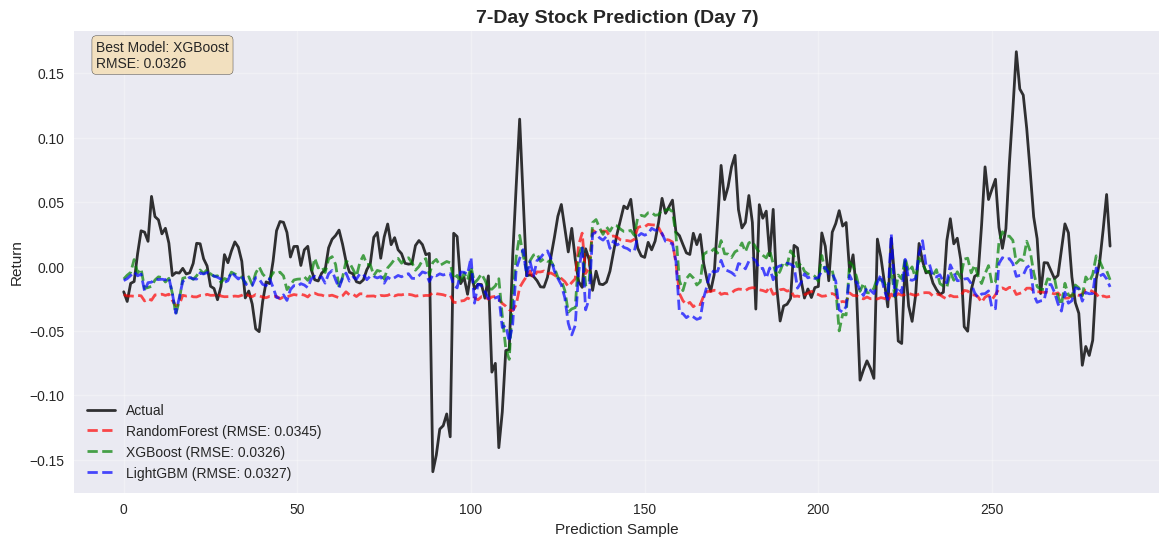

In [ ]:
# Visualization of 7-day Prediction Results (Only 2 Charts)

fig, ax = plt.subplots(figsize=(14,6))

model_names = ['RandomForest','XGBoost','LightGBM']
colors = {'RandomForest':'red','XGBoost':'green','LightGBM':'blue'}

pred_len = 7

# actual values
actual = ml_results['RandomForest']['actuals']
actual_day7 = actual[:, -1]

ax.plot(actual_day7,
        color='black',
        linewidth=2,
        label='Actual',
        alpha=0.8)

for model in model_names:

    predictions = ml_results[model]['predictions']
    rmse = ml_results[model]['rmse']

    pred_day7 = predictions[:, -1]

    ax.plot(pred_day7,
            color=colors[model],
            linewidth=2,
            linestyle='--',
            label=f'{model} (RMSE: {rmse:.4f})',
            alpha=0.7)

ax.set_title("7-Day Stock Prediction (Day 7)", fontsize=14, fontweight="bold")
ax.set_xlabel("Prediction Sample")
ax.set_ylabel("Return")
ax.legend()
ax.grid(alpha=0.3)

best_model = min(model_names, key=lambda m: ml_results[m]['rmse'])

ax.text(
    0.02,0.98,
    f"Best Model: {best_model}\nRMSE: {ml_results[best_model]['rmse']:.4f}",
    transform=ax.transAxes,
    verticalalignment="top",
    bbox=dict(boxstyle="round",facecolor="wheat",alpha=0.8)
)

plt.show()

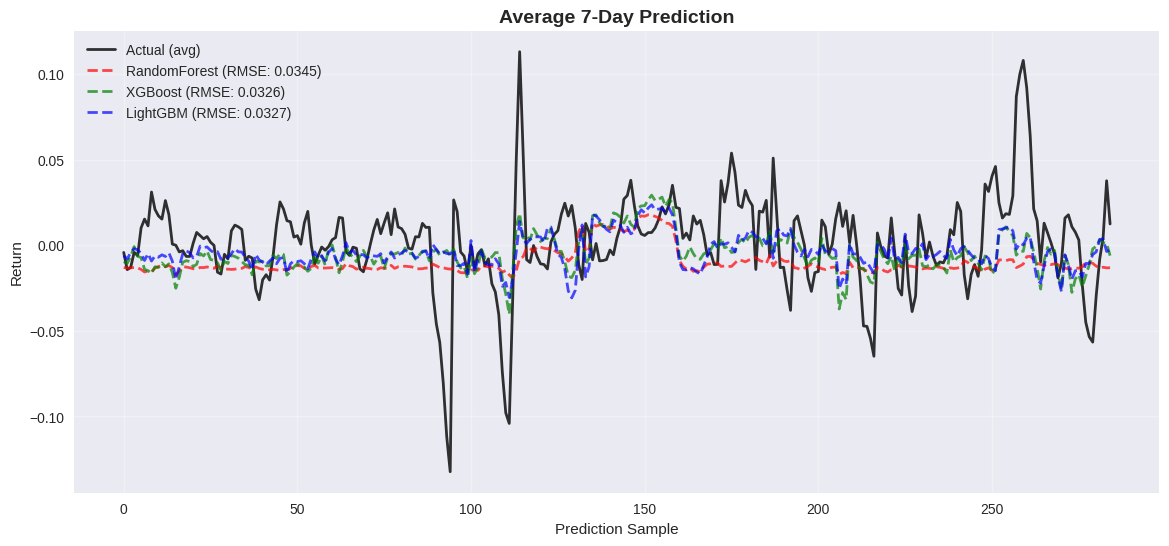

In [ ]:
fig, ax = plt.subplots(figsize=(14,6))

actual = ml_results['RandomForest']['actuals']
actual_avg = actual.mean(axis=1)

ax.plot(actual_avg,
        color='black',
        linewidth=2,
        label='Actual (avg)',
        alpha=0.8)

for model in model_names:

    predictions = ml_results[model]['predictions']
    rmse = ml_results[model]['rmse']

    pred_avg = predictions.mean(axis=1)

    ax.plot(pred_avg,
            color=colors[model],
            linewidth=2,
            linestyle='--',
            label=f'{model} (RMSE: {rmse:.4f})',
            alpha=0.7)

ax.set_title("Average 7-Day Prediction", fontsize=14, fontweight="bold")
ax.set_xlabel("Prediction Sample")
ax.set_ylabel("Return")
ax.legend()
ax.grid(alpha=0.3)

plt.show()

## Feature importance

Saved SHAP values to shap_values_RandomForest.csv


Feature Importance for RandomForest


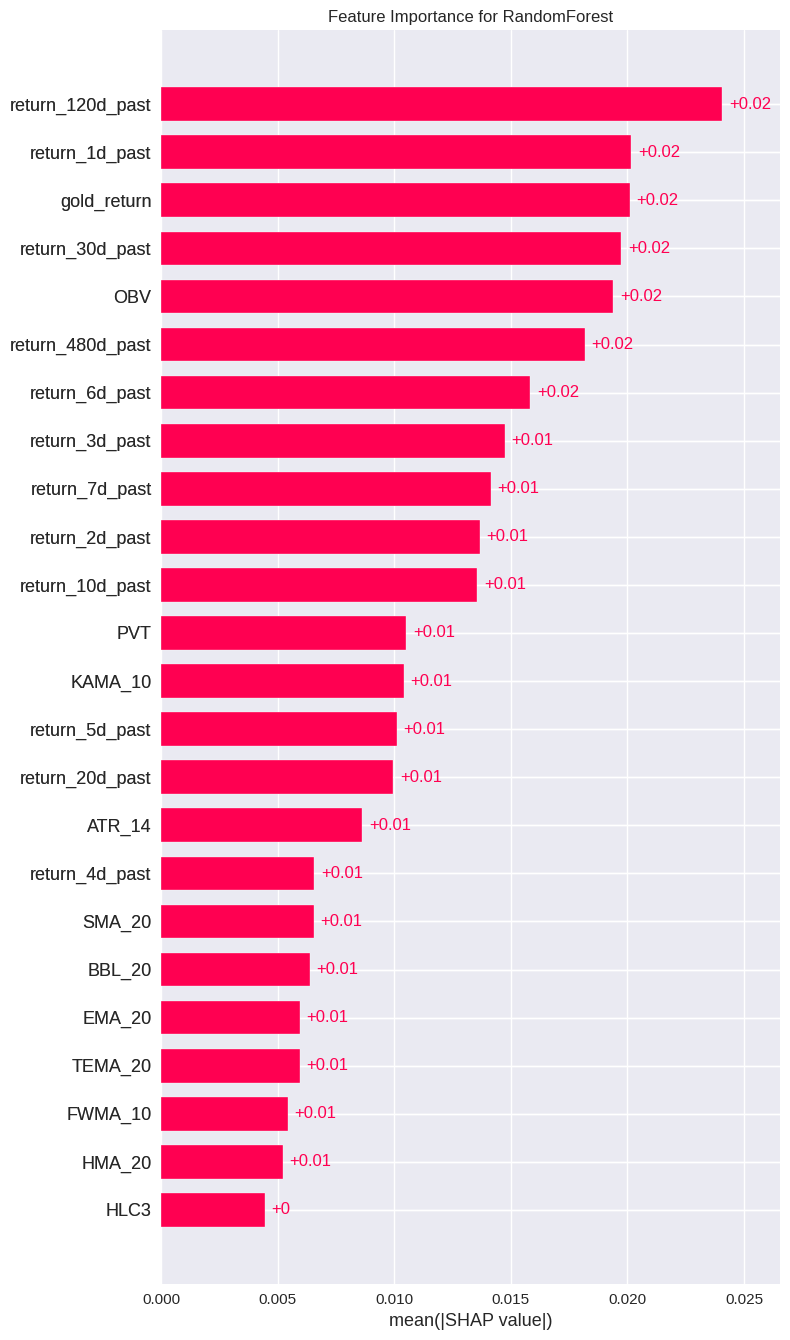

Saved SHAP values to shap_values_XGBoost.csv


Feature Importance for XGBoost


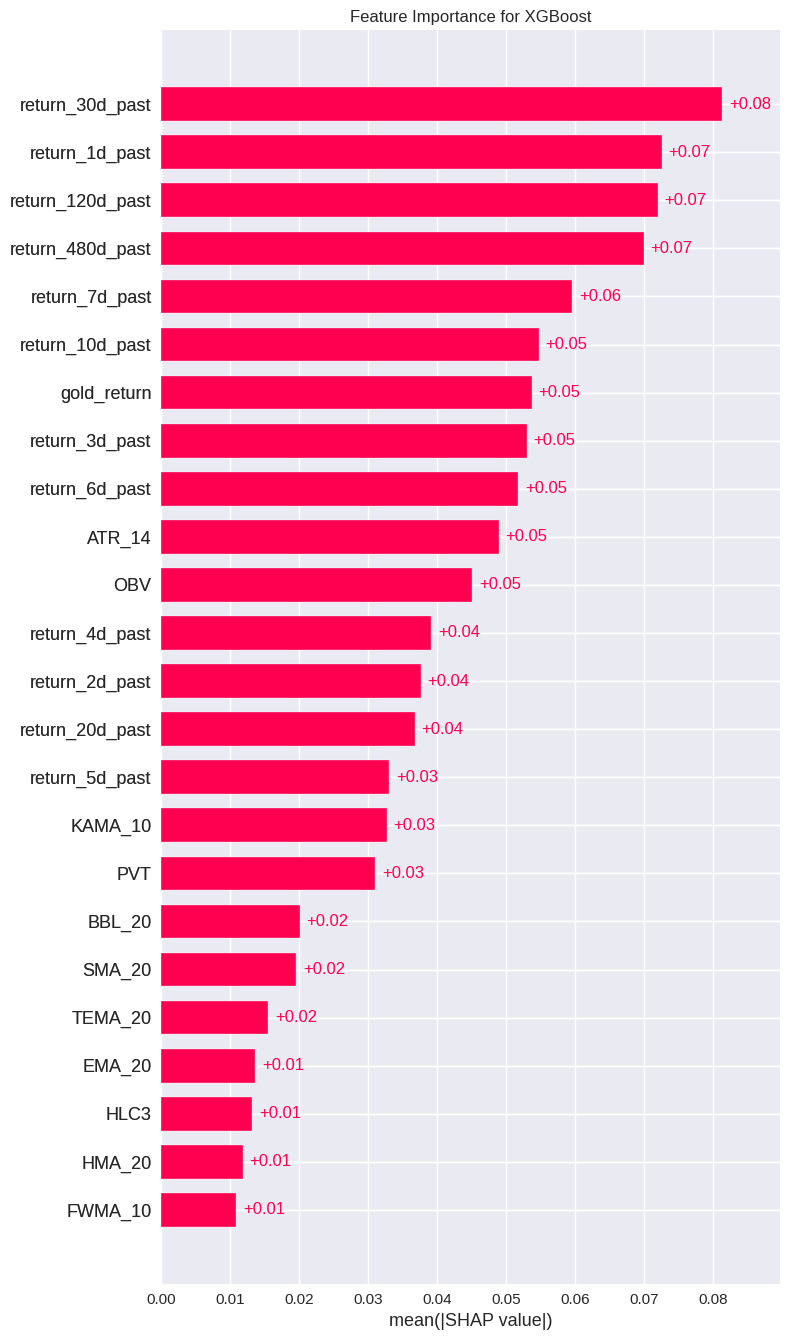

Saved SHAP values to shap_values_LightGBM.csv


Feature Importance for LightGBM


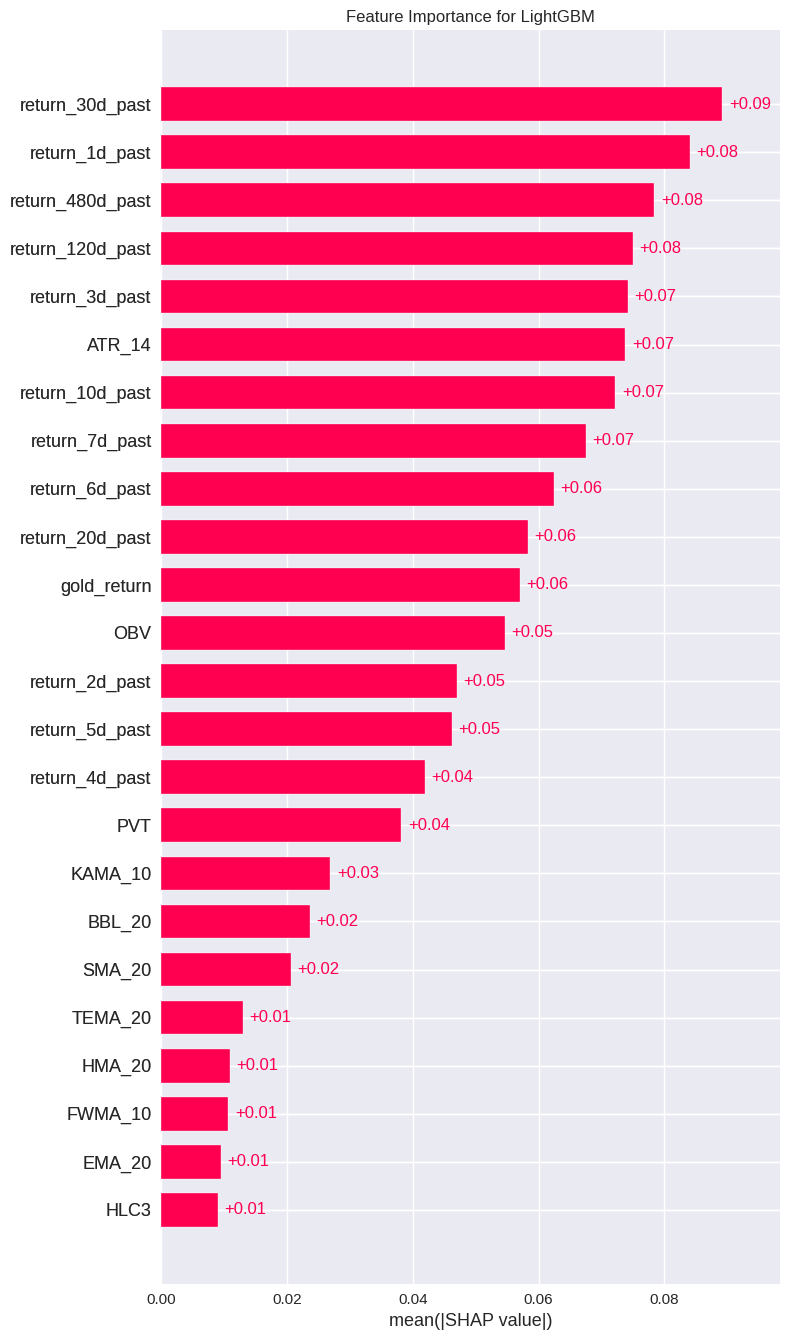

In [ ]:
import shap
import matplotlib.pyplot as plt
import pandas as pd

def save_shap_to_csv(shap_values, X, feature_cols, model_name):
    """
    Save SHAP values to CSV file
    """
    shap_df = pd.DataFrame(shap_values, columns=feature_cols)
    shap_df["sample_index"] = range(len(shap_df))

    # Save file
    filename = f"shap_values_{model_name}.csv"
    shap_df.to_csv(filename, index=False)

    print(f"Saved SHAP values to {filename}")


models = {
    "RandomForest": rf,
    "XGBoost": xgb,
    "LightGBM": lgbm
}

for name, model in models.items():

    explainer = shap.TreeExplainer(model.estimators_[0])

    shap_values_for_first_output = explainer.shap_values(X_train)
    expected_value_for_first_output = explainer.expected_value

    # Save SHAP values to CSV
    save_shap_to_csv(
        shap_values_for_first_output,
        X_train,
        feature_cols,
        name
    )

    explanation_object = shap.Explanation(
        values=shap_values_for_first_output,
        base_values=expected_value_for_first_output,
        data=X_train,
        feature_names=feature_cols
    )

    print("\n")
    print(f"Feature Importance for {name}")

    shap.plots.bar(explanation_object, show=False, max_display=25)

    plt.title(f"Feature Importance for {name}")
    plt.tight_layout()
    plt.show()

In [ ]:
df.to_csv("stock_data.csv", index=False)